In [13]:
# Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import os

# Config
%matplotlib inline
sns.set_theme(style="whitegrid", palette="pastel")

In [14]:
# Datasets
datasets = [
    'dataset1/',
    'dataset2/',
    'dataset3/',
    'dataset4/',
    'dataset5/'
]

folders = [
    'EarliestSetting4tele',
    'Random4tele',
    'ShortestSlew4tele',
    'tsp4',
    'tspcRoundRobin4',
    'tspcLoadBal4',
    'tspcKmean4',
    'tspcRightAsc4',
    'tspcKMeanEarlySetting4'
]

folder_name_map = {
    "EarliestSetting4tele": "Earliest Setting",
    "Random4tele": "Random",
    "ShortestSlew4tele": "Shortest Slew",
    "tsp4": "MTSP Gurobi",
    "tspcRoundRobin4": "MTSP Concorde (RRP)",
    "tspcLoadBal4": "MTSP Concorde (LBP)",
    "tspcKmean4": "MTSP Concorde (KmP)",
    "tspcRightAsc4": "MTSP Concorde (RAP)",
    "tspcKMeanEarlySetting4": "MTSP Concorde (KmP + ES)"
}

dataset_dfs = {}

for dataset in datasets:
    dataset_name = os.path.basename(os.path.normpath(dataset)) or dataset.strip('/')

    stats_list = []

    for folder in folders:
        folder_path = os.path.join(dataset, folder)
        csv_files = glob.glob(os.path.join(folder_path, '*.csv'))
    
        raw_folder_name = os.path.basename(os.path.normpath(folder))
        folder_name = folder_name_map.get(raw_folder_name, raw_folder_name)
    
        print(f"Processing {dataset_name} - {folder_name} with {len(csv_files)} files.")
    
        for file in csv_files:
            try:
                df = pd.read_csv(file, header=4)
                df.columns = df.columns.str.strip()
    
                # Compute total duration: sum Duration over all telescopes
                df['No'] = pd.to_numeric(df['No'], errors='coerce')
                total_duration = df['No'].sum()
    
                df['Wait time'] = pd.to_numeric(df['Wait time'], errors='coerce')
                total_observation = df['Wait time'].sum()
    
                stats_list.append({
                    'File': os.path.basename(file),
                    'Folder': folder_name,
                    'Total Duration': total_duration/4,
                    'Observation Time': total_observation/4
                })
    
            except Exception as e:
                print(f"Error processing {file}: {e}")

    
    dataset_df = pd.DataFrame(stats_list)
    dataset_dfs[dataset_name] = dataset_df



Processing dataset1 - Earliest Setting with 10 files.
Processing dataset1 - Random with 10 files.
Processing dataset1 - Shortest Slew with 10 files.
Processing dataset1 - MTSP Gurobi with 10 files.
Processing dataset1 - MTSP Concorde (RRP) with 10 files.
Processing dataset1 - MTSP Concorde (LBP) with 5 files.
Processing dataset1 - MTSP Concorde (KmP) with 8 files.
Processing dataset1 - MTSP Concorde (RAP) with 7 files.
Processing dataset1 - MTSP Concorde (KmP + ES) with 6 files.
Processing dataset2 - Earliest Setting with 10 files.
Processing dataset2 - Random with 10 files.
Processing dataset2 - Shortest Slew with 10 files.
Processing dataset2 - MTSP Gurobi with 10 files.
Processing dataset2 - MTSP Concorde (RRP) with 5 files.
Processing dataset2 - MTSP Concorde (LBP) with 5 files.
Processing dataset2 - MTSP Concorde (KmP) with 6 files.
Processing dataset2 - MTSP Concorde (RAP) with 6 files.
Processing dataset2 - MTSP Concorde (KmP + ES) with 6 files.
Processing dataset3 - Earliest Se

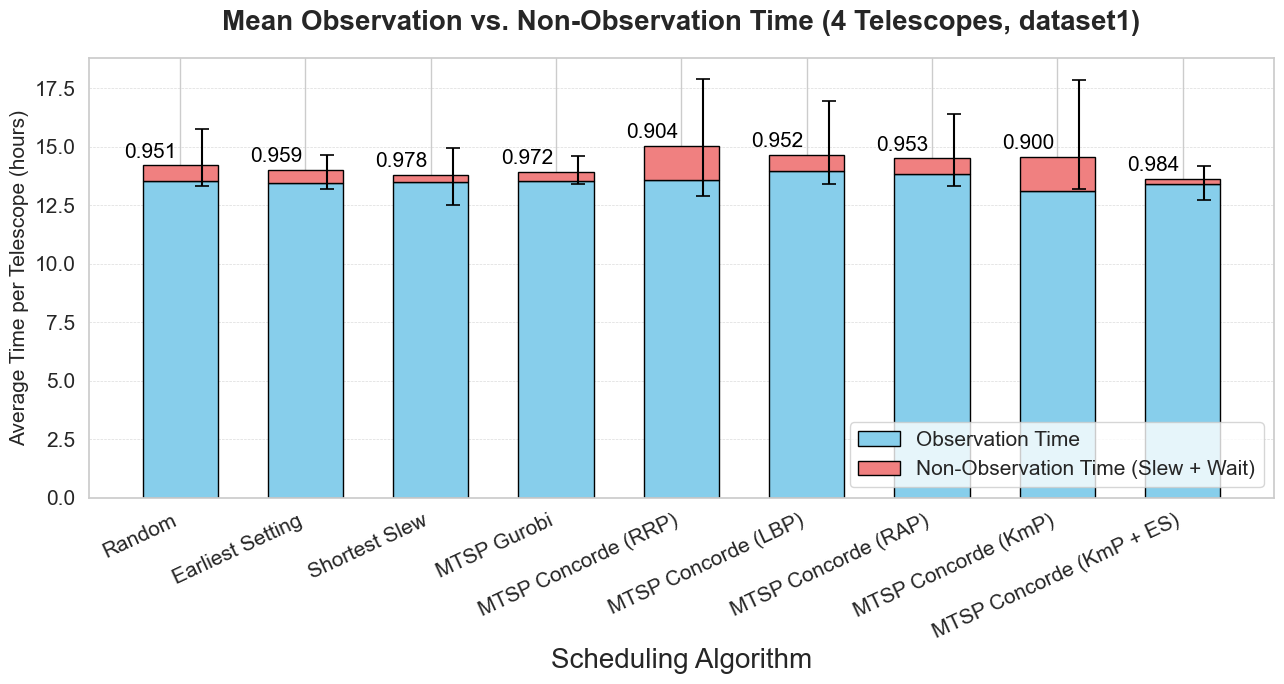

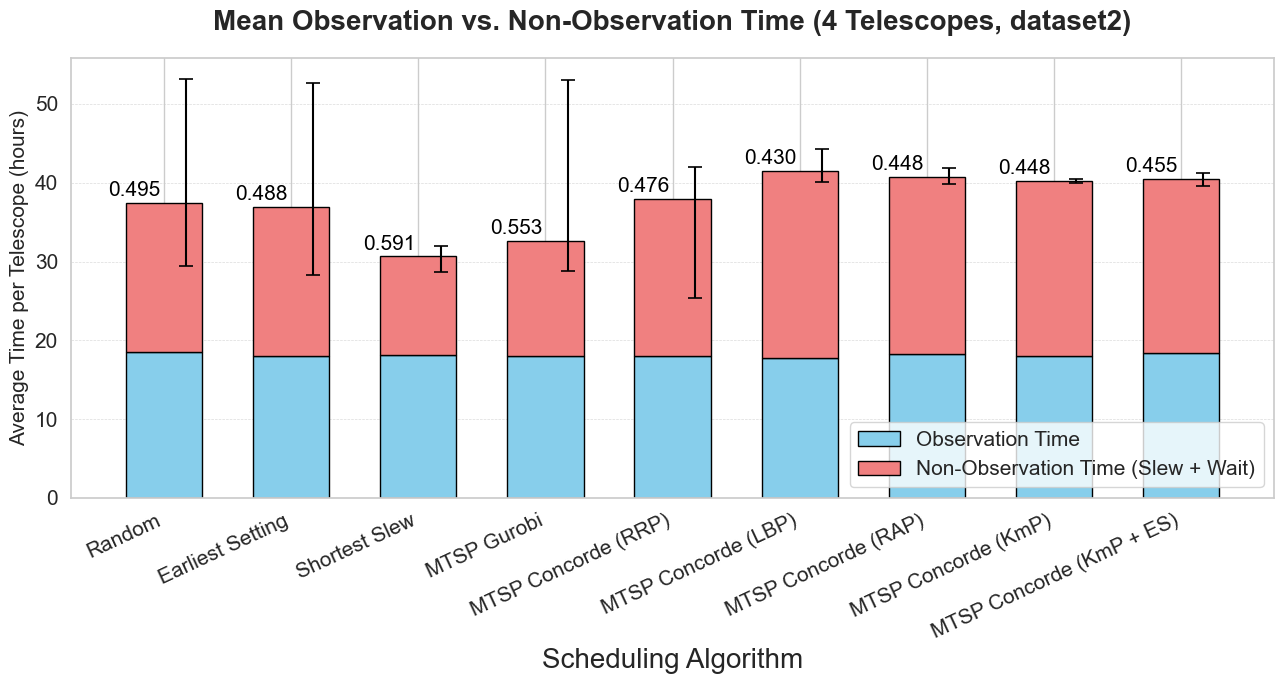

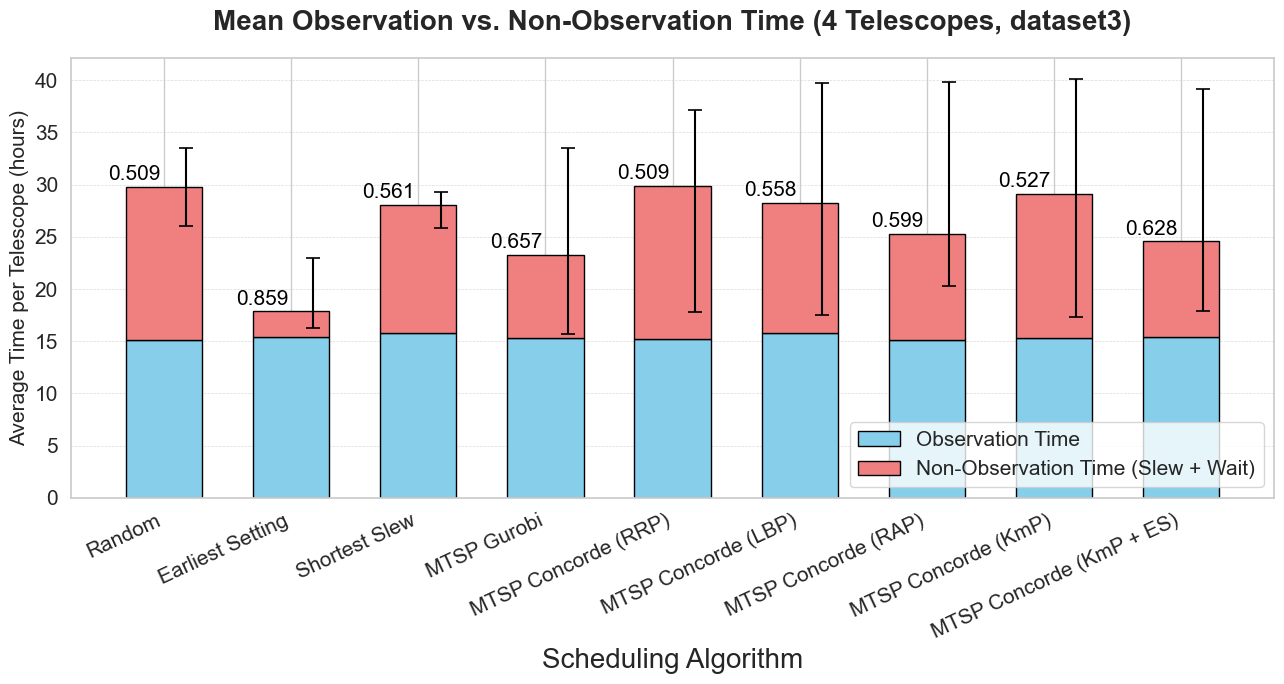

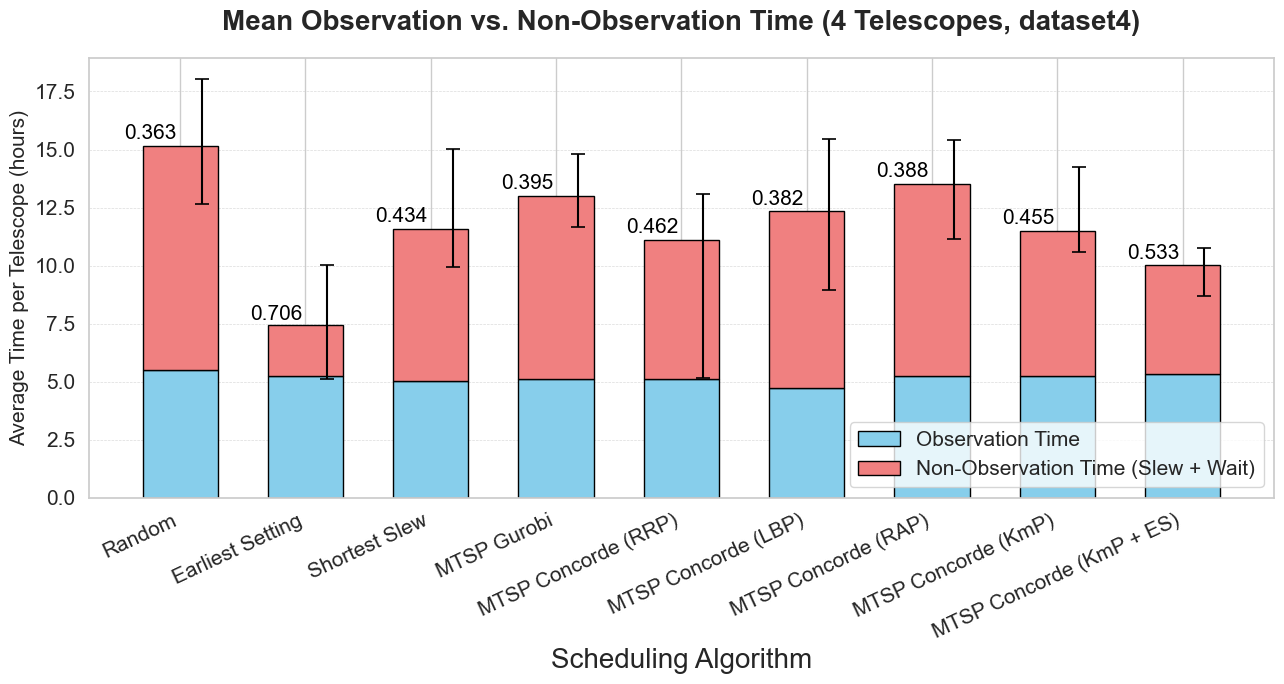

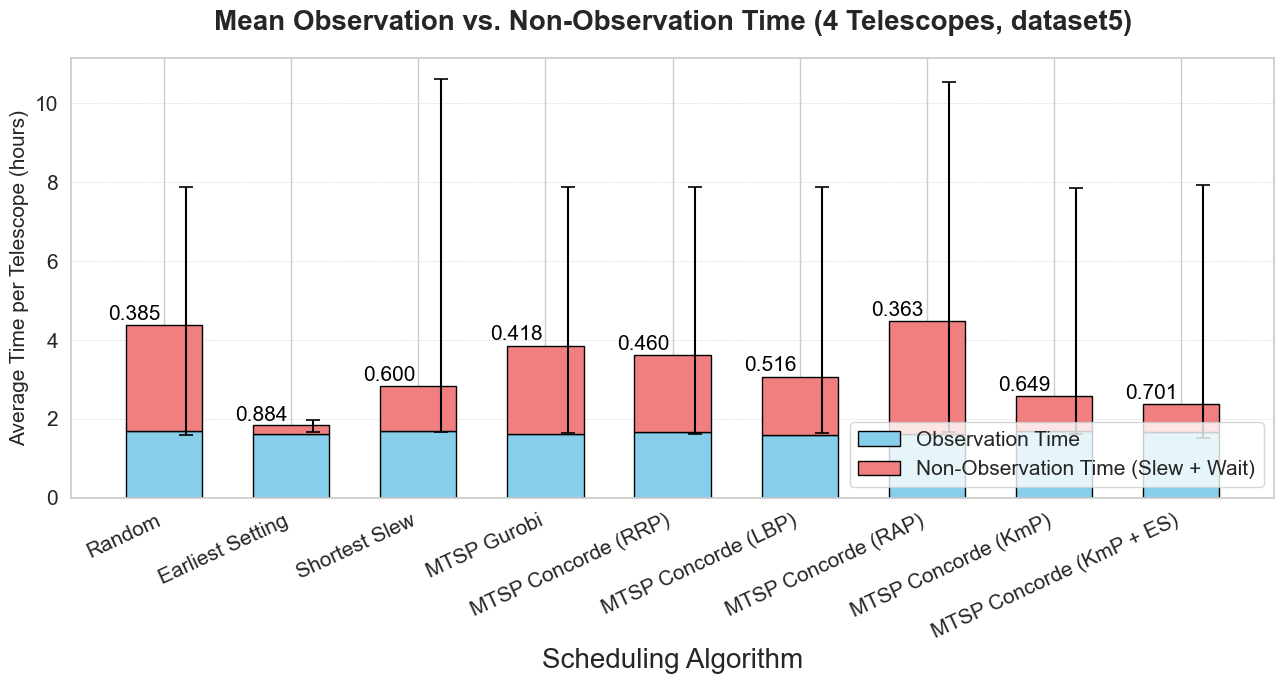

In [24]:
import matplotlib.pyplot as plt
import pandas as pd

# Replace this with your actual dataset_dfs dictionary
# dataset_dfs = { ... }

# Horizontal offset for spacing text/error bar left/right
offset = 0.025

for dataset_name, df in dataset_dfs.items():
    if df.empty:
        print(f"Skipping {dataset_name} because it has no data.")
        continue

    # Aggregate metrics: mean, min, max
    grouped = df.groupby('Folder').agg({
        'Total Duration': ['mean', 'min', 'max'],
        'Observation Time': ['mean', 'min', 'max']
    })

    # Flatten MultiIndex columns
    grouped.columns = ['_'.join(col).strip() for col in grouped.columns.values]
    summary = grouped.reset_index()

    # Derived values
    summary['Non-Observation Time_mean'] = summary['Total Duration_mean'] - summary['Observation Time_mean']

    # Sort order
    desired_order = [
        "Random",
        "Earliest Setting",
        "Shortest Slew",
        "MTSP Gurobi",
        "MTSP Concorde (RRP)",
        "MTSP Concorde (LBP)",
        "MTSP Concorde (RAP)",
        "MTSP Concorde (KmP)",
        "MTSP Concorde (KmP + ES)"
    ]
    summary['Folder'] = pd.Categorical(summary['Folder'], categories=desired_order, ordered=True)
    summary = summary.sort_values('Folder')

    # X positions
    x = range(len(summary))

    # Plot
    plt.figure(figsize=(13, 7))
    bar_width = 0.6

    # Plot stacked bars
    plt.bar(x, summary['Observation Time_mean'], label='Observation Time', 
            color='skyblue', edgecolor='black', width=bar_width)
    plt.bar(x, summary['Non-Observation Time_mean'], bottom=summary['Observation Time_mean'],
            label='Non-Observation Time (Slew + Wait)', color='lightcoral', edgecolor='black', width=bar_width)

    # Error bars: Total Duration (min to max), slightly to the right of each bar
    total_err_lower = summary['Total Duration_mean'] - summary['Total Duration_min']
    total_err_upper = summary['Total Duration_max'] - summary['Total Duration_mean']

    plt.errorbar([xi + offset + 0.15 for xi in x], summary['Total Duration_mean'], 
                 yerr=[total_err_lower, total_err_upper],
                 fmt='none', ecolor='black', capsize=5, capthick=1.2)

    # Observation ratio (proportion), slightly to the left of top of each bar
    observation_ratio = summary['Observation Time_mean'] / summary['Total Duration_mean']
    for i, (obs, total) in enumerate(zip(summary['Observation Time_mean'], summary['Total Duration_mean'])):
        plt.text(i - offset, total + 0.01 * total,
                 f"{observation_ratio.iloc[i]:.3f}",
                 ha='right', va='bottom', fontsize=15, color='black')

    # Format
    plt.title(f"Mean Observation vs. Non-Observation Time (4 Telescopes, {dataset_name})", fontsize=20, weight='bold', pad=20)
    plt.ylabel("Average Time per Telescope (hours)", fontsize=15)
    plt.xlabel("Scheduling Algorithm", fontsize=20)
    plt.xticks(ticks=x, labels=summary['Folder'], rotation=25, ha='right', fontsize=15)
    plt.yticks(fontsize=15)
    plt.grid(axis='y', linestyle='--', linewidth=0.5, alpha=0.7)
    plt.legend(loc='lower right', fontsize=15)
    plt.tight_layout()   
    plt.show()
